# Hierarchical Clustering in Machine Learning

###  DEF:
Hierarchical Clustering is an unsupervised machine learning algorithm used to group similar data points into clusters.
It creates a tree-like structure called a dendrogram, which shows how clusters are formed.

Unlike K-means clustering, hierarchical clustering does not require specifying the number of clusters initially.

### Types of Hierarchical Clustering

There are two types:

#### 1. Agglomerative Hierarchical Clustering (Bottom-Up)

Initially, each data point is treated as a separate cluster.
The two closest clusters are merged repeatedly.
This process continues until all points become one cluster.
#### Steps
Consider each point as an individual cluster.
Compute distances between clusters.
Merge the nearest clusters.
Recalculate distances.
Repeat until only one cluster remains.

This is the most commonly used hierarchical clustering method.

#### 2. Divisive Hierarchical Clustering (Top-Down)
Starts with all data points in one cluster.
Splits the cluster repeatedly into smaller clusters.
#### Steps
Put all points into one cluster.
Divide the cluster into smaller clusters.
Continue splitting until each point becomes separate.
### Dendrogram

A dendrogram is a tree diagram used to visualize hierarchical clustering.

Important Points
Each merge is represented by a horizontal line.
The height shows the distance between clusters.
By cutting the dendrogram at a certain height, we obtain the required number of clusters.


### Distance Measures Used

Hierarchical clustering uses distance metrics such as:

Euclidean Distance
Manhattan Distance
Cosine Distance
Linkage Methods

Linkage determines how distance between clusters is calculated.

1. Single Linkage

Distance between the nearest points of two clusters.

2. Complete Linkage

Distance between the farthest points of two clusters.

3. Average Linkage

Average distance between all pairs of points.

4. Ward’s Method

Minimizes variance within clusters.

Example

Suppose we have students grouped based on marks.

Students with similar marks are merged together.
Gradually, groups become larger.
Final dendrogram shows relationships among all students.
Advantages
No need to specify number of clusters initially.
Easy to visualize using dendrogram.
Works well for small datasets.
Can identify nested clusters.
Disadvantages
Computationally expensive for large datasets.
Sensitive to noise and outliers.
Once clusters are merged, they cannot be undone.
Applications

Hierarchical clustering is used in:

Customer segmentation
Document classification
Image segmentation
Bioinformatics (gene analysis)
Recommendation systems

### Difference Between K-Means and Hierarchical Clustering
K-Means	Hierarchical Clustering
Need to specify K initially	No need initially
Fast for large datasets	Slower
Produces flat clusters	Produces tree structure
Uses centroids	Uses distance matrix
Simple Definition

Hierarchical clustering is an unsupervised learning technique that groups similar data points into clusters by forming a hierarchy or tree-like structure called a dendrogram.

### how to calculate distane between the clusters???
 Euclidean distance = sqrt(x1 - x2)^2 + (y2 - y1)^2

 #### Distance between two clusters 
1. measure distance b/w two closest points.
2. measure distance bewtween  two furthest points (far)
3. average distance ( take the average distance betwwen the different points og clusters )
4. distance between centroids 

In [19]:
# same as k-means but different process

# it is of two types 
# 1. Agglomerative Hierarchical Clustering (Bottom-Up) -- starting from bottom and bilding cluster till up

# working:
#  1. make each data point a single point cluster  ( that form n clusters)
#  2. take two closest data points and make them one cluster ( that forms n -1 clusters)
#  3. take two closest data clusters  and make them one cluster ( that forms n -2 clusters)
#  4 . repaet step 3 untill there is only one cluster ( atlast we will have one big cluster)

# 2. Divisive Hierarchical Clustering (Top-Down)--- starting from top ,making clusters till bottom

# dendogram

### def :
dendrogram is a tree-like diagram used in Hierarchical Clustering in machine learning to show how data points are grouped together step by step.

### how dendogram works ?

Working of Dendrograms in Machine Learning

A dendrogram works by visually showing how clusters are formed in Hierarchical Clustering.

It represents:

The order in which data points are merged
The similarity/distance between clusters
The hierarchical relationship among clusters
Step-by-Step Working of Dendrogram
#### Step 1: Start with Individual Data Points

Initially:

Every data point is treated as a separate cluster.

Example:

A   B   C   D

So initially:

Cluster 1 = A
Cluster 2 = B
Cluster 3 = C
Cluster 4 = D
#### Step 2: Calculate Distance Matrix

The algorithm calculates the distance between all data points using measures such as:

Euclidean distance
Manhattan distance
Cosine distance

Example:

	    A	B	C	D
1. A	0	2	8	9
2. B	2	0	7	10
3. C	8	7	0	3
4. D	9	10	3	0
#### Step 3: Merge the Closest Clusters

The smallest distance is selected.

Here:

Distance between A and B = 2
So A and B merge first.

Dendrogram shows this merge at height 2.
 A   B   C   D
\   /

#### Step 4: Recalculate Distances

After merging A and B:

Distances are recalculated between the new cluster (AB) and other clusters.

This depends on linkage methods:

Single linkage
Complete linkage
Average linkage
Ward linkage
#### Step 5: Merge Next Closest Clusters

Suppose:

C and D have distance = 3

They merge next.

   A   B   C   D
    \ /     \ /
#### Step 6: Continue Until One Cluster Remains

Now there are:

Cluster AB
Cluster CD

These are merged finally.

        ________
       |        |
     __|__    __|__
    |     |  |     |
    A     B  C     D


### How Height Works in Dendrogram

The vertical height where clusters join represents the distance between them.

Lower height → highly similar clusters
Higher height → less similar clusters
Selecting Number of Clusters

A horizontal line is drawn across the dendrogram.

The number of branches cut by the line gives the number of clusters.

Example:

        ________
       |        |
     __|__    __|__
    |     |  |     |
    A     B  C     D
-----------------------

If the line cuts:

2 branches → 2 clusters




### Linkage Methods Used
1. Single Linkage

Uses minimum distance between clusters.

2. Complete Linkage

Uses maximum distance.

3. Average Linkage

Uses average distance.

4. Ward’s Method

Minimizes variance within clusters.

### Advantages of Dendrogram Working
Clear visualization
No need to predefine clusters
Easy cluster interpretation
### Limitations
Slow for large datasets
Difficult to read for many points
Sensitive to noisy data


#### implementati0n

#### importing libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#### importing the datasets

In [21]:
dataset = pd.read_csv('Mall_Customers.csv')
x = dataset.iloc[:,[3,4]].values

#### Using dendograms to find optimal number of clusters

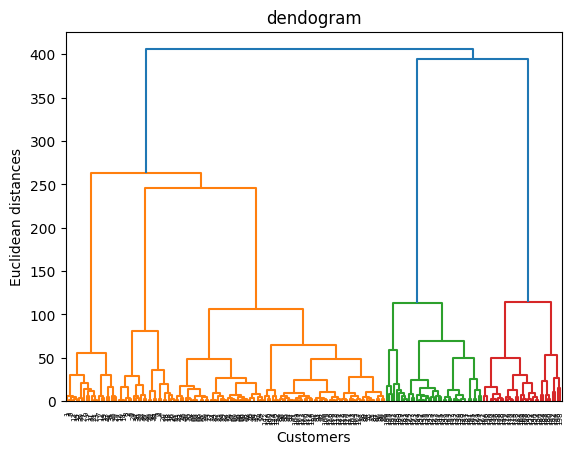

In [22]:
import scipy.cluster.hierarchy as sch

# from sch importing linkage parameter and its has parameter like  ---- 
# 1. matrix of feature ( which we are to use to find the number of clusters)
# 2.clustering technique (argument name used for implemeting is 'method') --- in this the max used technique is  ---> miimum vriance (while implementing we use as 'ward')minimize the variance of clusters
dendogram = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title ('dendogram')
plt.xlabel('Customers') # here the x aix ae the features but observation  (cutomers)

plt.ylabel('Euclidean distances')# in y axis , we will pass euclidean distance to calculate distance between the dataspoints , made as clusters based on distance again calculates the distance for to from clusters 
plt.show()

#### training hierarchical clustering in the dataset 

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

# train
y_hc = hc.fit_predict(x)

In [25]:
print(y_hc)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


In [28]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

# train
y_hc = hc.fit_predict(x)

#### visualising the clusters


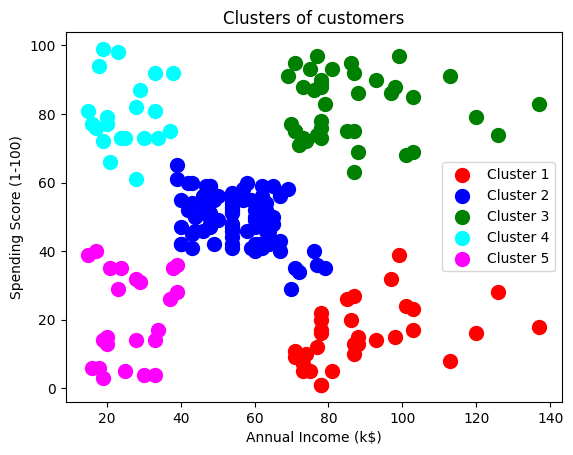

In [27]:
plt.scatter(x[y_hc == 0, 0], x[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x[y_hc == 1, 0], x[y_hc== 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_hc == 2, 0], x[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(x[y_hc == 3, 0], x[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(x[y_hc == 4, 0], x[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

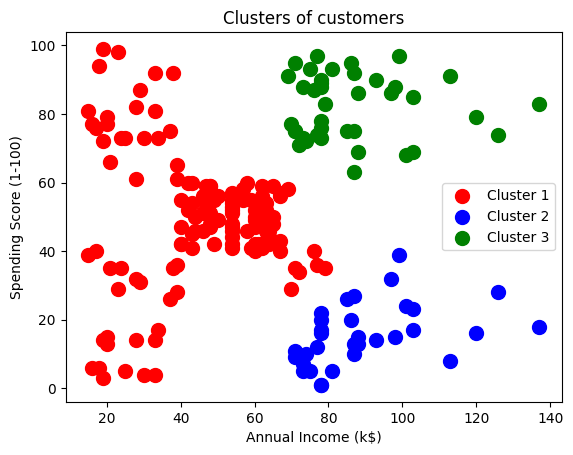

In [29]:
plt.scatter(x[y_hc == 0, 0], x[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x[y_hc == 1, 0], x[y_hc== 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_hc == 2, 0], x[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')


plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
# NOTE : Hierarchical Clustering do not performs better than K-Means on large datasets
# PERFORMED AT within cluster variance